# Training Pipeline: Sovereign Dialect-Bridge

| Bagian | Metode | Tipe | GPU |
|--------|--------|------|-----|
| Section 5 | mT5-base Fine-tuned | Abstraktif Multilingual | ~5 GB |
| Section 6 | IndoBART V2 Fine-tuned | Abstraktif Indonesia | ~4 GB |
| Section 7 | NER-Based | Ekstraktif Rule-Based | ~2 GB |
| Section 8 | TextRank | Ekstraktif Unsupervised | CPU |

# Setup Env


In [1]:
import os, sys

IN_KAGGLE = os.path.exists('/kaggle/input')
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ENV = "Kaggle" if IN_KAGGLE else ("Colab" if IN_COLAB else "Lokal")
print(f"Environment: {ENV}")


Environment: Kaggle


In [2]:
import torch

if IN_KAGGLE:
    # Selalu isolasi ke GPU-0, bahkan di T4x2.
    # Alasan: HuggingFace Trainer di Jupyter (single-process) otomatis pakai DataParallel
    # saat 2 GPU terdeteksi. DataParallel mereplikasi model di setiap GPU dan menyalurkan
    # semua gradient sync ke GPU-0 → GPU-0 bisa terisi 12+ GB untuk model 580M saja.
    # Single-GPU jauh lebih efisien di setting notebook (vs torchrun multi-process).
    os.environ["CUDA_VISIBLE_DEVICES"]   = "0"
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    os.environ["NCCL_P2P_DISABLE"]       = "1"
    os.environ["PYTORCH_ALLOC_CONF"]     = "expandable_segments:True"

    num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
    print(f"GPU aktif (setelah isolasi): {num_gpus}")
    print("Kaggle env variables set.")

GPU aktif (setelah isolasi): 1
Kaggle env variables set.


In [3]:
if IN_KAGGLE:
    os.system('pip install -q "unsloth[kaggle-new]" --upgrade')
    os.system('pip install -q --no-deps trl peft accelerate bitsandbytes')
elif IN_COLAB:
    os.system('pip install -q "unsloth[colab-new]" --upgrade')
    os.system('pip install -q --no-deps trl peft accelerate bitsandbytes')

os.system('pip install -q datasets rouge-score transformers sumy PySastrawi')
print("Semua package terinstall.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.6/869.6 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.9.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 66.7 MB/s eta 0:00:00
Semua package terinstall.


# Import Library Conf and CONST Var Hyperparamaeter


In [4]:
import os, re, gc, sys, json, inspect
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from rouge_score import rouge_scorer
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForSequenceClassification,
    Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    pipeline,
)
from datasets import Dataset as HFDataset
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer as SumyTokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from nltk.corpus import stopwords
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

_TOK_KWARG = (
    "processing_class"
    if "processing_class" in inspect.signature(Trainer.__init__).parameters
    else "tokenizer"
)
print(f"Import selesai. Trainer tokenizer kwarg: '{_TOK_KWARG}'")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Import selesai. Trainer tokenizer kwarg: 'processing_class'


In [ ]:
# Konfigurasi parameter
TRAIN_SUBSET   = 5000    # jumlah sampel training yang dipakai
N_VAL          = 500     # jumlah sampel validasi (subset dev set)
N_TEST         = 500     # jumlah sampel evaluasi
MAX_INPUT_LEN  = 512     # panjang token input maksimum
MAX_TARGET_LEN = 128     # panjang token ringkasan maksimum
NUM_EPOCHS     = 3       # epoch training
BATCH_SIZE     = 4       # batch size per perangkat
GRAD_ACCUM     = 4       # gradient accumulation — effective batch: 16 (T4×1) / 32 (T4×2)
LEARNING_RATE  = 1e-4    # optimal untuk mT5-base dan IndoBART V2

# Model yang digunakan
MT5_MODEL          = "google/mt5-base"                           # abstraktif multilingual
INDOBART_V2_MODEL  = "indobenchmark/indobart-v2"                 # abstraktif Indonesia
NER_MODEL          = "cahya/bert-base-indonesian-NER"            # NER extractive

In [6]:
# Deteksi perangkat komputasi secara otomatis
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = "mps"    # Apple Silicon M1/M2/M3
else:
    DEVICE = "cpu"

USE_FP16 = DEVICE == "cuda"   # fp16 hanya tersedia di CUDA
USE_BF16 = DEVICE == "mps"    # bf16 tersedia di Apple Silicon

print(f"Perangkat  : {DEVICE.upper()}")
print(f"Presisi    : fp16={USE_FP16}, bf16={USE_BF16}")
if DEVICE == "mps":
    print("Tip Mac M1 : set TRAIN_SUBSET=1000 dan NUM_EPOCHS=1 agar lebih cepat")
elif DEVICE == "cpu":
    print("Tip CPU    : training mT5 akan sangat lambat, disarankan di GPU")


Perangkat  : CUDA
Presisi    : fp16=True, bf16=False


In [7]:
# Konfigurasi path dataset dan output model
BASE = '/kaggle/input/datasets/fadhlannurrachman/dataset' if IN_KAGGLE else '../dataset'

INDOSUM_DIR  = Path(BASE) / 'indosum'
NUSAX_MT_DIR = Path(BASE) / 'nusax/datasets/mt'
OUTPUT_DIR   = Path('/kaggle/working') if IN_KAGGLE else Path('..')
MODEL_DIR    = OUTPUT_DIR / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MT5_PATH          = str(MODEL_DIR / 'mt5-indosum')
INDOBART_V2_PATH  = str(MODEL_DIR / 'indobart-v2-indosum')
NER_PATH          = str(MODEL_DIR / 'ner')

print(f"IndoSum ada    : {INDOSUM_DIR.exists()}")
print(f"NusaX ada      : {NUSAX_MT_DIR.exists()}")
print(f"Model dir      : {MODEL_DIR.resolve()}")
print(f"  mT5          : {MT5_PATH}")
print(f"  IndoBART V2  : {INDOBART_V2_PATH}")
print(f"  NER          : {NER_PATH}")

IndoSum ada    : True
NusaX ada      : True
Model dir      : /kaggle/working/model
  mT5          : /kaggle/working/model/mt5-indosum
  IndoBART V2  : /kaggle/working/model/indobart-v2-indosum
  NER          : /kaggle/working/model/ner


# Load & Preview Dataset

IndoSum — 19.000+ artikel berita Indonesia dengan ringkasan referensi manusia.
Sumber: [kata-ai/indosum](https://github.com/kata-ai/indosum)

NusaX — 1.000 kalimat paralel dalam 12 bahasa (Jawa, Sunda, Minang, Bali, dll).
Sumber: [IndoNLP/nusa-crowd](https://github.com/IndoNLP/nusa-crowd)


In [8]:
def flatten_tokens(nested):
    """Ubah struktur token bersarang IndoSum menjadi teks biasa."""
    if not nested:
        return ""
    if isinstance(nested[0][0], list):
        # paragraf: list[list[list[str]]]
        sentences = [" ".join(sent) for para in nested for sent in para]
        return ". ".join(sentences)
    # summary: list[list[str]]
    return " ".join(" ".join(sent) for sent in nested)


def load_indosum(data_dir, split, fold=1):
    """Muat satu split IndoSum, kembalikan list of dict {text, summary, category}."""
    path = Path(data_dir) / f"{split}.0{fold}.jsonl"
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            records.append({
                "text":     flatten_tokens(r["paragraphs"]),
                "summary":  flatten_tokens(r["summary"]),
                "category": r["category"],
            })
    return records


In [9]:
train_data  = load_indosum(INDOSUM_DIR, "train", fold=1)
val_data    = load_indosum(INDOSUM_DIR, "dev",   fold=1)
test_data   = load_indosum(INDOSUM_DIR, "test",  fold=1)
test_subset = test_data[:N_TEST]

def avg_words(records, key):
    return sum(len(r[key].split()) for r in records) / len(records)

print(f"{'Split':<8} {'N':>6} {'Avg Teks (kata)':>18} {'Avg Ringkasan (kata)':>22}")
print("-" * 58)
for name, data in [("train", train_data), ("dev", val_data), ("test", test_data)]:
    print(f"{name:<8} {len(data):>6} {avg_words(data, 'text'):>18.1f} {avg_words(data, 'summary'):>22.1f}")
print()
print(f"Subset evaluasi: {len(test_subset)} sampel dari test set")

Split         N    Avg Teks (kata)   Avg Ringkasan (kata)
----------------------------------------------------------
train     14262              346.8                   67.7
dev         750              348.6                   67.7
test       3762              343.3                   67.7

Subset evaluasi: 500 sampel dari test set


In [10]:
# Preview 3 sampel dari IndoSum
print("=" * 70)
print("Contoh Data IndoSum")
print("=" * 70)
for i, r in enumerate(train_data[:3]):
    print()
    print(f"[Sampel {i+1}] Kategori: {r['category']}")
    print(f"  Teks     : {r['text'][:200]}...")
    print(f"  Ringkasan: {r['summary'][:120]}...")

Contoh Data IndoSum

[Sampel 1] Kategori: tajuk utama
  Teks     : Jakarta , CNN Indonesia - - Dokter Ryan Thamrin , yang terkenal lewat acara Dokter Oz Indonesia , meninggal dunia pada Jumat ( 4 / 8 ) dini hari .. Dokter Lula Kamal yang merupakan selebriti sekaligus...
  Ringkasan: Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan Thamrin menyebut kawannya itu sudah sakit sejak se...

[Sampel 2] Kategori: teknologi
  Teks     : Selfie ialah salah satu tema terpanas di kalangan produsen smartphone , bahkan menjadi senjata andalan beberapa brand terkenal .. Anda mungkin berpikir bahwa saat ini , pasar handset spesialis selfie ...
  Ringkasan: Asus memperkenalkan   ZenFone generasi keempat dan keduanya sama-sama dibekali setup kamera ganda di depan . Mereka adal...

[Sampel 3] Kategori: hiburan
  Teks     : Jakarta , CNN Indonesia - - Dinas Pariwisata Provinsi Bengkulu kembali menggelar kegiatan Bimbingan Teknis ( Bimtek ) SDM Kepariwisataan dalam menyongson " Visit 2

In [11]:
# Load NusaX Machine Translation dataset (kalimat paralel antar dialek)
mt_all = pd.concat([
    pd.read_csv(NUSAX_MT_DIR / "train.csv"),
    pd.read_csv(NUSAX_MT_DIR / "valid.csv"),
    pd.read_csv(NUSAX_MT_DIR / "test.csv"),
], ignore_index=True)

DIALECT_COLS = [
    "javanese", "sundanese", "minangkabau", "balinese",
    "banjarese", "buginese", "madurese", "acehnese", "ngaju", "toba_batak",
]

print(f"NusaX MT: {len(mt_all)} kalimat paralel, {len(DIALECT_COLS)} dialek")
print()
print("Contoh kalimat paralel — 3 dialek vs Bahasa Indonesia:")
print("=" * 70)
idx = 0
print(f"  {'Indonesia':<14}: {str(mt_all['indonesian'].iloc[idx])[:80]}")
for d in ["javanese", "sundanese", "minangkabau"]:
    val = mt_all[d].iloc[idx]
    print(f"  {d.capitalize():<14}: {str(val)[:80]}")


NusaX MT: 1000 kalimat paralel, 10 dialek

Contoh kalimat paralel — 3 dialek vs Bahasa Indonesia:
  Indonesia     : Nikmati cicilan 0% hingga 12 bulan untuk pemesanan tiket pesawat air asia dengan
  Javanese      : Nikmatono cicilan 0% sampek 12 sasi dinggo pesen tiket kapal air asia nganggo ke
  Sundanese     : Nikmati angsuran 0% dugi ka 12 bulan kanggo mesen tiket pasawat air asia nganggo
  Minangkabau   : Nikmati cicilan 0% sampai 12 bulan untuak pamasanan tiket pisawat air asia jo ka


## Section 3: EDA Singkat

Eksplorasi awal untuk memahami karakteristik dataset.
EDA lengkap (analisis kosakata per dialek, lexicon, distribusi detail) tersedia di `eda.ipynb`.


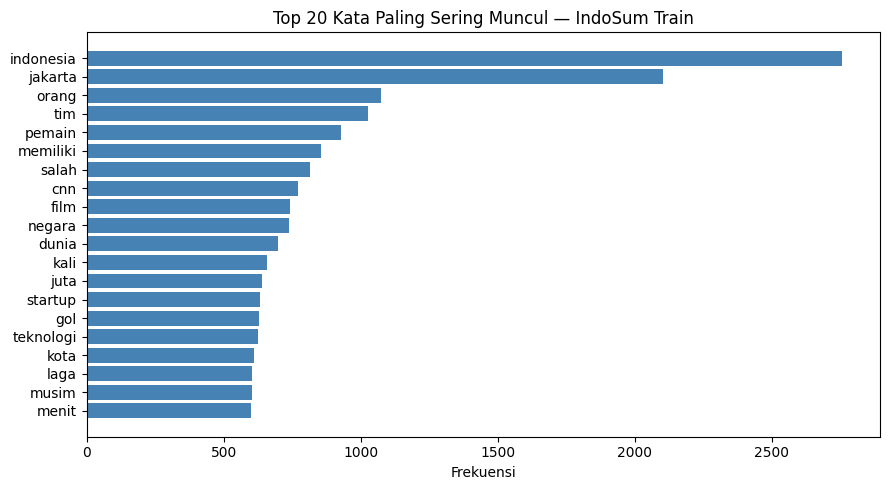

In [12]:
# Grafik 1: Top 20 kata paling sering muncul (exclude stopwords)
id_stopwords = set(stopwords.words("indonesian"))
all_text = " ".join(r["text"] for r in train_data[:2000])  # sampel 2000 agar cepat
tokens   = [
    w.lower() for w in all_text.split()
    if w.isalpha() and w.lower() not in id_stopwords and len(w) > 2
]
top20 = Counter(tokens).most_common(20)
words, counts = zip(*top20)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(reversed(words)), list(reversed(counts)), color="steelblue")
ax.set_title("Top 20 Kata Paling Sering Muncul — IndoSum Train")
ax.set_xlabel("Frekuensi")
plt.tight_layout()
plt.show()


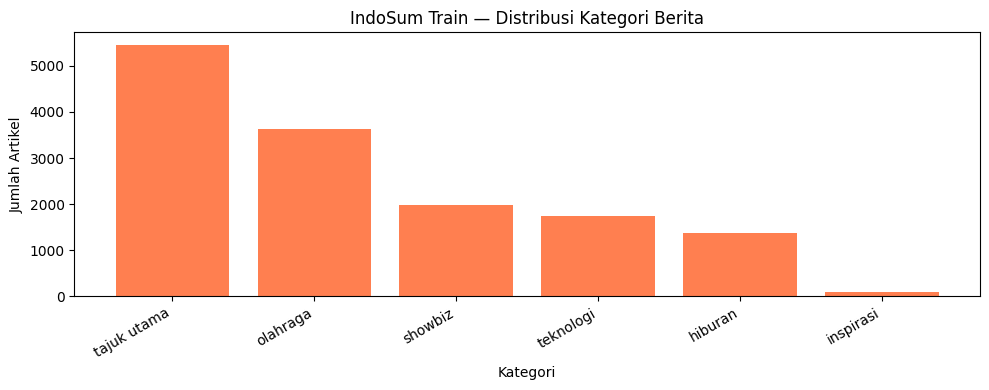

In [13]:
# Grafik 2: Distribusi kategori berita IndoSum
cats = Counter(r["category"] for r in train_data)
cats_sorted = dict(sorted(cats.items(), key=lambda x: -x[1]))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cats_sorted.keys(), cats_sorted.values(), color="coral")
ax.set_title("IndoSum Train — Distribusi Kategori Berita")
ax.set_ylabel("Jumlah Artikel")
ax.set_xlabel("Kategori")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [14]:
# Statistik ringkasan dataset
text_lens = [len(r["text"].split())    for r in train_data]
sum_lens  = [len(r["summary"].split()) for r in train_data]
ratios    = [s / t for t, s in zip(text_lens, sum_lens) if t > 0]

print("Statistik IndoSum Train:")
print(f"  Panjang rata-rata artikel   : {sum(text_lens)/len(text_lens):.0f} kata")
print(f"  Panjang rata-rata ringkasan : {sum(sum_lens)/len(sum_lens):.0f} kata")
print(f"  Compression ratio rata-rata : {sum(ratios)/len(ratios):.3f}")
print(f"  Artinya: ringkasan ~{sum(ratios)/len(ratios)*100:.0f}% dari panjang artikel")
print()
print("Statistik NusaX MT:")
print(f"  Total kalimat paralel : {len(mt_all)}")
print(f"  Jumlah dialek         : {len(DIALECT_COLS)}")
print(f"  Dialek tersedia       : {', '.join(DIALECT_COLS)}")


Statistik IndoSum Train:
  Panjang rata-rata artikel   : 347 kata
  Panjang rata-rata ringkasan : 68 kata
  Compression ratio rata-rata : 0.225
  Artinya: ringkasan ~23% dari panjang artikel

Statistik NusaX MT:
  Total kalimat paralel : 1000
  Jumlah dialek         : 10
  Dialek tersedia       : javanese, sundanese, minangkabau, balinese, banjarese, buginese, madurese, acehnese, ngaju, toba_batak


## Section 4: Text Preprocessing

Pipeline preprocessing untuk summarization dialek Indonesia — **urutan langkah penting**:

| Langkah | Fungsi | Alasan Urutan |
|---------|--------|---------------|
| 1 | `clean_noise` | Hapus URL dan karakter noise sebelum koreksi dialek |
| 2 | `correct_dialect_slang` | Lakukan sebelum lowercase agar regex case-insensitive bekerja optimal |
| 3 | `normalize_case_punct` | Lowercase dan unifikasi tanda baca |
| 4 | `stem_text` | Stemming setelah teks bersih dan konsisten |

**Catatan penting:** Stopwords dan angka **tidak dihapus** karena keduanya penting untuk
menjaga konteks kalimat dalam summarization (berbeda dengan klasifikasi/sentimen).


In [15]:

_stemmer = StemmerFactory().create_stemmer()

# Kata-kata yang tidak boleh di-stem (singkatan, nama dinas, dll)
STEM_STOPWORDS = {
    "rt", "rw", "jl", "bpbd", "dinas", "kelurahan", "kecamatan",
    "lapor", "laporan", "pengaduan", "warga", "masyarakat",
}

# Kamus koreksi kata dialek ke Bahasa Indonesia standar
DIALECT_SLANG_DICT = {
    # Jawa
    "mboten": "tidak", "kulo": "saya", "wonten": "ada", "sampun": "sudah",
    "teng": "di", "ngajeng": "depan", "griya": "rumah", "tigang": "tiga",
    "wulan": "bulan", "sanget": "sekali", "nggih": "ya", "mangke": "nanti",
    "panjenengan": "anda", "lare": "anak", "dalan": "jalan", "omah": "rumah",
    "ndandosi": "memperbaiki", "menawi": "kalau",
    # Sunda
    "naha": "kenapa", "punten": "permisi", "mun": "kalau", "keur": "sedang",
    "deui": "lagi", "wae": "saja", "teu": "tidak", "ieu": "ini",
    "eta": "itu", "abdi": "saya", "urang": "kita", "atuh": "dong",
    "mah": "sih", "enya": "iya", "hoyong": "ingin",
    # Minang
    "ambo": "saya", "indak": "tidak", "den": "saya", "awak": "kita",
    "apak": "bapak", "uda": "kakak", "alah": "sudah", "dek": "adik",
    "ndak": "tidak", "beko": "nanti", "ado": "ada", "kampuang": "kampung",
    # Betawi
    "kagak": "tidak", "aye": "saya", "gue": "saya",
    "nyang": "yang", "ente": "kamu", "babe": "bapak",
    "emang": "memang", "udah": "sudah",
    # Bali
    "tiang": "saya", "nenten": "tidak", "mangkin": "sekarang",
    "dumun": "dulu", "sampunang": "jangan",
    # Banjar
    "ulun": "saya", "pian": "kamu", "kada": "tidak", "banar": "benar",
    "handak": "mau",
    # Batak
    "au": "saya", "ndang": "tidak", "nunga": "sudah", "dohot": "dan",
    # Bugis
    "engka": "ada", "degaga": "tidak ada", "matu": "sudah",
    # Melayu
    "tak": "tidak", "dah": "sudah", "nak": "mau",
    # Aceh
    "lon": "saya", "hana": "tidak ada", "nyan": "itu", "nyoe": "ini",
    # Madura
    "sengko": "saya", "arapa": "kenapa",
}

# Compile regex sekali agar efisien saat dipakai berulang
_SLANG_RE = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in DIALECT_SLANG_DICT) + r")\b",
    flags=re.IGNORECASE,
)

print(f"Stemmer PySastrawi : siap")
print(f"Kamus dialek       : {len(DIALECT_SLANG_DICT)} entri dari 10 dialek")


Stemmer PySastrawi : siap
Kamus dialek       : 79 entri dari 10 dialek


In [16]:

def clean_noise(text):
    """Langkah 1: Hapus URL, karakter noise, dan whitespace berlebih."""
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"[^\x00-\x7FÀ-ɏḀ-ỿ]", " ", text)
    text = re.sub(r"(.)\1{3,}", r"\1\1", text)     # karakter berulang lebih dari 3x
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

# Demo
sample = "Jalan rusaaakkk!!! Cek https://maps.google.com   untuk detailnya."
print("Sebelum:", sample)
print("Sesudah:", clean_noise(sample))


Sebelum: Jalan rusaaakkk!!! Cek https://maps.google.com   untuk detailnya.
Sesudah: Jalan rusaaakkk!!! Cek untuk detailnya.


In [17]:

def correct_dialect_slang(text):
    """Langkah 2: Koreksi kata dialek ke Bahasa Indonesia standar."""
    return _SLANG_RE.sub(
        lambda m: DIALECT_SLANG_DICT.get(m.group(0).lower(), m.group(0)),
        text,
    )

# Demo
sample = "Kulo mboten mangertos kenapa jalan teng ngajeng griya sampun rusak."
print("Sebelum:", sample)
print("Sesudah:", correct_dialect_slang(sample))


Sebelum: Kulo mboten mangertos kenapa jalan teng ngajeng griya sampun rusak.
Sesudah: saya tidak mangertos kenapa jalan di depan rumah sudah rusak.


In [ ]:

def normalize_case_punct(text):
    """Langkah 3: Lowercase dan normalisasi tanda baca berlebih."""
    text = text.lower()
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\?{2,}", "?", text)
    text = re.sub(r"\.{2,}", "...", text) # .... -> ...
    text = re.sub(r"\s([.,!?;:])", r"\1", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

# Demo
sample = "Jalan RUSAK PARAH !!! sudah 3 bulan ..."
print("Sebelum:", sample)
print("Sesudah:", normalize_case_punct(sample))


Sebelum: Jalan RUSAK PARAH !!! sudah 3 bulan ...
Sesudah: jalan rusak parah! sudah 3 bulan...


In [19]:

def stem_text(text):
    """Langkah 4: Stemming Bahasa Indonesia dengan PySastrawi."""
    tokens = text.split()
    return " ".join(
        tok if tok in STEM_STOPWORDS else _stemmer.stem(tok)
        for tok in tokens
    )

# Demo
sample = "pemerintah sedang memperbaiki jalan yang rusak di daerah tersebut"
print("Sebelum:", sample)
print("Sesudah:", stem_text(sample))


Sebelum: pemerintah sedang memperbaiki jalan yang rusak di daerah tersebut
Sesudah: perintah sedang baik jalan yang rusak di daerah sebut


In [20]:
def preprocess_extractive(text, apply_dialect=False):
    """Preprocessing untuk metode EKSTRAKTIF (TextRank, NER): dengan stemming."""
    text = clean_noise(text)
    if apply_dialect:
        text = correct_dialect_slang(text)
    text = normalize_case_punct(text)
    text = stem_text(text)
    return text


def preprocess_abstractive(text, apply_dialect=False):
    """Preprocessing untuk metode ABSTRAKTIF (mT5, IndoBART V2): TANPA stemming.

    mT5 dan IndoBART tidak pernah dilatih pada teks yang di-stem.
    Stemming pada input abstraktif merusak performa secara signifikan.
    """
    text = clean_noise(text)
    if apply_dialect:
        text = correct_dialect_slang(text)
    text = normalize_case_punct(text)
    return text


# Demo: perbedaan keluaran kedua fungsi
teks_jawa = "pak, jalan teng ngajeng griya kulo rusak parah. sampun tigang wulan mboten wonten ingkang memperbaiki!"
print("Input (Jawa):")
print(teks_jawa)
print()
print("preprocess_extractive (dengan stem, untuk TextRank/NER):")
print(preprocess_extractive(teks_jawa, apply_dialect=True))
print()
print("preprocess_abstractive (tanpa stem, untuk mT5/IndoBART V2):")
print(preprocess_abstractive(teks_jawa, apply_dialect=True))

Input (Jawa):
pak, jalan teng ngajeng griya kulo rusak parah. sampun tigang wulan mboten wonten ingkang memperbaiki!

preprocess_extractive (dengan stem, untuk TextRank/NER):
pak jalan di depan rumah saya rusak parah sudah tiga bulan tidak ada ingkang baik

preprocess_abstractive (tanpa stem, untuk mT5/IndoBART V2):
pak, jalan di depan rumah saya rusak parah. sudah tiga bulan tidak ada ingkang memperbaiki!


## Section 5: Method 1 — mT5-base Fine-tuning (Abstractive)

mT5 (multilingual T5) adalah model encoder-decoder yang sudah dilatih pada 101 bahasa
termasuk Bahasa Indonesia. Dengan fine-tuning pada IndoSum, model belajar menghasilkan
ringkasan **abstraktif** — kalimat baru yang tidak harus ada di teks asli.

Menggunakan **mT5-base** (580M parameter) — lebih besar dari mT5-small (300M),
menghasilkan ringkasan yang lebih koheren dan natural.

**Catatan preprocessing:** Input mT5 menggunakan `preprocess_abstractive()` — **TANPA stemming**.
mT5 tidak pernah dilatih pada teks yang di-stem; stemming akan merusak performa secara signifikan.

**Estimasi waktu training (TRAIN_SUBSET=5000, 3 epoch):**

| Platform | Estimasi |
|----------|----------|
| Kaggle T4 (GPU) | ~90–150 menit |
| Mac M1 Air (MPS) | ~120–200 menit |
| Mac M1 Air (CPU) | ~6–10 jam |

In [21]:
mt5_tokenizer = AutoTokenizer.from_pretrained(MT5_MODEL)

def preprocess_mt5(examples):
    """Tokenisasi dataset untuk training mT5: input 'summarize: <teks>', target <ringkasan>."""
    inputs  = ["summarize: " + t for t in examples["text"]]
    targets = examples["summary"]

    model_inputs = mt5_tokenizer(
        inputs, max_length=MAX_INPUT_LEN, truncation=True, padding=False,
    )
    labels = mt5_tokenizer(
        text_target=targets, max_length=MAX_TARGET_LEN, truncation=True, padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print(f"mT5 tokenizer dimuat: {MT5_MODEL}")


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

mT5 tokenizer dimuat: google/mt5-base


In [22]:
# Siapkan dataset HuggingFace untuk training — teks ASLI tanpa stemming (abstractive)
train_hf = HFDataset.from_list(train_data[:TRAIN_SUBSET])
val_hf   = HFDataset.from_list(val_data[:N_VAL])

train_tok = train_hf.map(preprocess_mt5, batched=True, remove_columns=train_hf.column_names)
val_tok   = val_hf.map(preprocess_mt5,   batched=True, remove_columns=val_hf.column_names)

print(f"Train tokenized: {len(train_tok)} sampel")
print(f"Val tokenized  : {len(val_tok)} sampel")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train tokenized: 5000 sampel
Val tokenized  : 500 sampel


In [23]:
# Load mT5 dan mulai training
mt5_model     = AutoModelForSeq2SeqLM.from_pretrained(MT5_MODEL)
mt5_model.config.tie_word_embeddings = False   # silence checkpoint weight mismatch warning
data_collator = DataCollatorForSeq2Seq(mt5_tokenizer, model=mt5_model, padding=True)

active_gpus = torch.cuda.device_count() if DEVICE == "cuda" else 0
eff_batch   = BATCH_SIZE * max(active_gpus, 1) * GRAD_ACCUM
print(f"GPU aktif       : {active_gpus} | Effective batch size: {eff_batch}")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM tersedia   : {free/1024**3:.1f} GB / {total/1024**3:.1f} GB")

mt5_args = Seq2SeqTrainingArguments(
    output_dir=MT5_PATH,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=2,           # eval + beam search butuh lebih banyak VRAM
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    optim="adamw_8bit",                     # optimizer 8-bit: hemat ~3.5 GB vs adamw_torch
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,   # batasi panjang generate saat eval
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
    dataloader_pin_memory=False,
    eval_accumulation_steps=4,
)

mt5_trainer = Seq2SeqTrainer(
    model=mt5_model,
    args=mt5_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    **{_TOK_KWARG: mt5_tokenizer},
)

print(f"Mulai training mT5 ({TRAIN_SUBSET} data, {NUM_EPOCHS} epoch, device={DEVICE})...")
mt5_trainer.train()
mt5_trainer.save_model(MT5_PATH)
mt5_tokenizer.save_pretrained(MT5_PATH)
print(f"Training selesai. Model disimpan di: {MT5_PATH}")

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training selesai. Model disimpan di: /kaggle/working/model/mt5-indosum


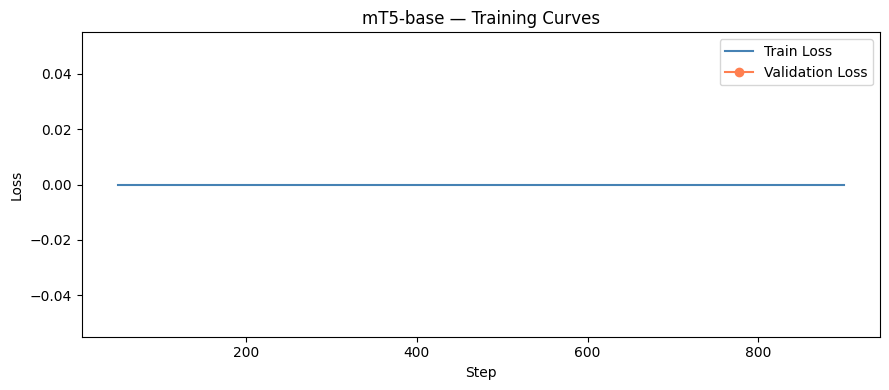

Final train loss : 0.0000
Best val loss    : nan


In [24]:
# Plot training curves mT5
_log          = mt5_trainer.state.log_history
_tr_steps     = [x["step"]      for x in _log if "loss"      in x and "eval_loss" not in x]
_tr_losses    = [x["loss"]      for x in _log if "loss"      in x and "eval_loss" not in x]
_val_steps    = [x["step"]      for x in _log if "eval_loss" in x]
_val_losses   = [x["eval_loss"] for x in _log if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(_tr_steps,  _tr_losses,  label="Train Loss",      color="steelblue")
ax.plot(_val_steps, _val_losses, label="Validation Loss", color="coral", marker="o")
ax.set_title("mT5-base — Training Curves")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final train loss : {_tr_losses[-1]:.4f}" if _tr_losses else "")
print(f"Best val loss    : {min(_val_losses):.4f}" if _val_losses else "")

In [25]:
# Generate prediksi mT5 pada subset evaluasi
mt5_model.eval()
if DEVICE != "cpu":
    mt5_model = mt5_model.to(DEVICE)

print(f"Menghasilkan prediksi mT5 pada {N_TEST} sampel...")
mt5_preds = []
for i, record in enumerate(test_subset):
    inputs = mt5_tokenizer(
        "summarize: " + record["text"],
        return_tensors="pt",
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    if DEVICE != "cpu":
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        out = mt5_model.generate(**inputs, max_new_tokens=MAX_TARGET_LEN, num_beams=4)
    mt5_preds.append(mt5_tokenizer.decode(out[0], skip_special_tokens=True))
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N_TEST} selesai")

print("Selesai. Contoh prediksi:")
print(mt5_preds[0][:200])


Menghasilkan prediksi mT5 pada 500 sampel...
  50/500 selesai
  100/500 selesai
  150/500 selesai
  200/500 selesai
  250/500 selesai
  300/500 selesai
  350/500 selesai
  400/500 selesai
  450/500 selesai
  500/500 selesai
Selesai. Contoh prediksi:
<extra_id_0> , ” ungkapnya ..


In [26]:
# Bersihkan GPU memory sebelum section berikutnya
del mt5_model, mt5_trainer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory GPU dibersihkan.")

Memory GPU dibersihkan.


## Section 6: Method 2 — IndoBART V2 Fine-tuning (Abstractive)

IndoBART V2 (`indobenchmark/indobart-v2`) adalah model BART yang **dipra-latih khusus
untuk Bahasa Indonesia** oleh IndoNLP/INLG. Berbeda dari mT5 yang multilingual (101 bahasa),
IndoBART V2 fokus penuh pada Bahasa Indonesia sehingga tokenizer-nya lebih efisien
untuk teks berbahasa Indonesia.

**Arsitektur:** encoder-decoder berbasis BART → output ringkasan abstraktif (kalimat baru).

**Perbedaan utama vs mT5:**
- IndoBART V2: monolingual Indonesia — vocabulary lebih padat untuk kata-kata Indonesia
- mT5: multilingual — lebih umum tapi overhead tokenisasi lebih besar per kata Indonesia

**Fallback:** Jika IndoBART V2 gagal dimuat (kompatibilitas transformers), otomatis
menggunakan **IndoT5** (`cahya/t5-base-indonesian-summarization-cased`) sebagai pengganti.

**Estimasi waktu training (TRAIN_SUBSET=5000, 3 epoch):**

| Platform | Estimasi |
|----------|---------|
| Kaggle T4 (GPU) | ~60–90 menit |
| Mac M1 Air (MPS) | ~90–150 menit |

In [27]:
# Load tokenizer IndoBART V2
_indobart_model_name = INDOBART_V2_MODEL
try:
    indobart_tokenizer = AutoTokenizer.from_pretrained(_indobart_model_name)
    # Cek apakah tokenizer memiliki language token id_ID (untuk forced_bos)
    INDOBART_BOS_ID = (
        indobart_tokenizer.lang_code_to_id.get("id_ID")
        if hasattr(indobart_tokenizer, "lang_code_to_id") else None
    )
    print(f"IndoBART V2 tokenizer   : {_indobart_model_name}")
    print(f"Vocab size              : {len(indobart_tokenizer)}")
    print(f"BOS token id_ID         : {INDOBART_BOS_ID}")
except Exception as _e:
    print(f"[WARNING] Gagal load IndoBART V2 tokenizer: {_e}")
    print("Fallback ke IndoT5 (cahya/t5-base-indonesian-summarization-cased)...")
    _indobart_model_name = "cahya/t5-base-indonesian-summarization-cased"
    indobart_tokenizer = AutoTokenizer.from_pretrained(_indobart_model_name)
    INDOBART_BOS_ID = None
    print(f"IndoT5 tokenizer dimuat : {_indobart_model_name}")


def preprocess_indobart(examples):
    """Tokenisasi dataset untuk IndoBART V2 / IndoT5 — tanpa stemming."""
    model_inputs = indobart_tokenizer(
        examples["text"], max_length=MAX_INPUT_LEN, truncation=True, padding=False,
    )
    labels = indobart_tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TARGET_LEN, truncation=True, padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


# Buat dataset HuggingFace — gunakan teks asli (abstractive, tanpa stemming)
train_hf_ib  = HFDataset.from_list(train_data[:TRAIN_SUBSET])
val_hf_ib    = HFDataset.from_list(val_data[:N_VAL])

train_tok_ib = train_hf_ib.map(preprocess_indobart, batched=True, remove_columns=train_hf_ib.column_names)
val_tok_ib   = val_hf_ib.map(preprocess_indobart,   batched=True, remove_columns=val_hf_ib.column_names)

print(f"Train tokenized (IndoBART): {len(train_tok_ib)} sampel")
print(f"Val tokenized   (IndoBART): {len(val_tok_ib)} sampel")

config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/303 [00:00<?, ?B/s]

[WARNING] Gagal load IndoBART V2 tokenizer: 'NoneType' object has no attribute 'from_pretrained'
Fallback ke IndoT5 (cahya/t5-base-indonesian-summarization-cased)...


config.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.07k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

IndoT5 tokenizer dimuat : cahya/t5-base-indonesian-summarization-cased


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train tokenized (IndoBART): 5000 sampel
Val tokenized   (IndoBART): 500 sampel


In [28]:
# Load model IndoBART V2 dan mulai training
_gen_kwargs = {}
try:
    indobart_model = AutoModelForSeq2SeqLM.from_pretrained(_indobart_model_name)
    if INDOBART_BOS_ID is not None:
        indobart_model.config.forced_bos_token_id = INDOBART_BOS_ID
        _gen_kwargs["forced_bos_token_id"] = INDOBART_BOS_ID
    print(f"Model dimuat: {_indobart_model_name}")
except Exception as _e:
    print(f"[ERROR] Gagal load model: {_e}")
    raise

data_collator_ib = DataCollatorForSeq2Seq(indobart_tokenizer, model=indobart_model, padding=True)

active_gpus = torch.cuda.device_count() if DEVICE == "cuda" else 0
eff_batch   = BATCH_SIZE * max(active_gpus, 1) * GRAD_ACCUM
print(f"GPU aktif       : {active_gpus} | Effective batch: {eff_batch}")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM tersedia   : {free/1024**3:.1f} GB / {total/1024**3:.1f} GB")

indobart_args = Seq2SeqTrainingArguments(
    output_dir=INDOBART_V2_PATH,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=2,           # eval + beam search butuh lebih banyak VRAM
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    optim="adamw_8bit",                     # optimizer 8-bit: hemat ~3.5 GB vs adamw_torch
    fp16=USE_FP16,
    bf16=USE_BF16,
    gradient_checkpointing=True,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LEN,   # batasi panjang generate saat eval
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
    dataloader_pin_memory=False,
    eval_accumulation_steps=4,
)

INDOBART_TRAINED = False
try:
    indobart_trainer = Seq2SeqTrainer(
        model=indobart_model,
        args=indobart_args,
        train_dataset=train_tok_ib,
        eval_dataset=val_tok_ib,
        data_collator=data_collator_ib,
        **{_TOK_KWARG: indobart_tokenizer},
    )
    print(f"Mulai training {_indobart_model_name} ({TRAIN_SUBSET} data, {NUM_EPOCHS} epoch, device={DEVICE})...")
    indobart_trainer.train()
    indobart_trainer.save_model(INDOBART_V2_PATH)
    indobart_tokenizer.save_pretrained(INDOBART_V2_PATH)
    INDOBART_TRAINED = True
    print(f"Training selesai. Model disimpan di: {INDOBART_V2_PATH}")
except Exception as _e:
    print(f"\n[WARNING] IndoBART V2 training gagal: {type(_e).__name__}: {_e}")
    print("Prediksi IndoBART V2 akan diisi string kosong — evaluasi tetap berjalan.")
    INDOBART_TRAINED = False
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Model dimuat: cahya/t5-base-indonesian-summarization-cased
GPU aktif       : 1 | Effective batch: 16
VRAM tersedia   : 12.2 GB / 14.6 GB
Mulai training cahya/t5-base-indonesian-summarization-cased (5000 data, 3 epoch, device=cuda)...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training selesai. Model disimpan di: /kaggle/working/model/indobart-v2-indosum


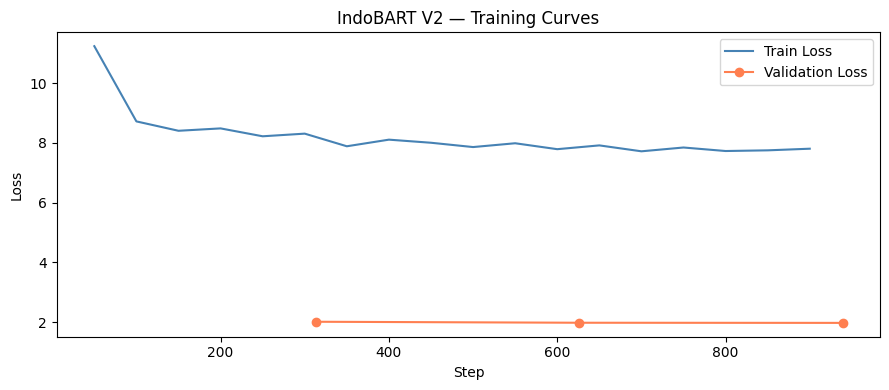

Final train loss : 7.8061
Best val loss    : 1.9744


In [29]:
# Plot training curves IndoBART V2
if INDOBART_TRAINED:
    _log_ib       = indobart_trainer.state.log_history
    _tr_steps_ib  = [x["step"]      for x in _log_ib if "loss"      in x and "eval_loss" not in x]
    _tr_losses_ib = [x["loss"]      for x in _log_ib if "loss"      in x and "eval_loss" not in x]
    _val_steps_ib = [x["step"]      for x in _log_ib if "eval_loss" in x]
    _val_loss_ib  = [x["eval_loss"] for x in _log_ib if "eval_loss" in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(_tr_steps_ib,  _tr_losses_ib, label="Train Loss",      color="steelblue")
    ax.plot(_val_steps_ib, _val_loss_ib,  label="Validation Loss", color="coral", marker="o")
    ax.set_title(f"IndoBART V2 — Training Curves")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Final train loss : {_tr_losses_ib[-1]:.4f}" if _tr_losses_ib else "")
    print(f"Best val loss    : {min(_val_loss_ib):.4f}"  if _val_loss_ib  else "")
else:
    print("[INFO] IndoBART V2 tidak dilatih — training curves tidak tersedia.")

In [30]:
# Generate prediksi IndoBART V2 pada subset evaluasi
if INDOBART_TRAINED:
    indobart_model.eval()
    if DEVICE != "cpu":
        indobart_model = indobart_model.to(DEVICE)

    print(f"Menghasilkan prediksi IndoBART V2 pada {N_TEST} sampel...")
    indobart_preds = []
    for i, record in enumerate(test_subset):
        inputs = indobart_tokenizer(
            record["text"],
            return_tensors="pt",
            max_length=MAX_INPUT_LEN,
            truncation=True,
        )
        if DEVICE != "cpu":
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            out = indobart_model.generate(
                **inputs,
                max_new_tokens=MAX_TARGET_LEN,
                num_beams=4,
                **_gen_kwargs,
            )
        indobart_preds.append(indobart_tokenizer.decode(out[0], skip_special_tokens=True))
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{N_TEST} selesai")
    print("Selesai. Contoh prediksi:")
    print(indobart_preds[0][:200])
else:
    indobart_preds = [""] * N_TEST
    print("[INFO] IndoBART V2 training gagal — prediksi diisi string kosong untuk evaluasi.")

Menghasilkan prediksi IndoBART V2 pada 500 sampel...
  50/500 selesai
  100/500 selesai
  150/500 selesai
  200/500 selesai
  250/500 selesai
  300/500 selesai
  350/500 selesai
  400/500 selesai
  450/500 selesai
  500/500 selesai
Selesai. Contoh prediksi:
Seorang warga Mesir yang dipercaya sebagai wanita terberat di dunia masuk sebuah rumah sakit di Abu Dhabi Kamis ( 5 / 5 ) , dimana ia akan melanjutkan perawatan setelah menjalankan operasi menurunkan 


In [31]:
# Bersihkan GPU memory sebelum section berikutnya
for _var in ["indobart_model", "indobart_trainer", "train_hf_ib", "train_tok_ib", "val_hf_ib", "val_tok_ib"]:
    try:
        del globals()[_var]
    except KeyError:
        pass
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory GPU dibersihkan.")

Memory GPU dibersihkan.


## Section 7: Method 3 — NER-Based Summarization (Extractive)

Pendekatan ini menggunakan Named Entity Recognition (NER) untuk menilai setiap kalimat
berdasarkan jumlah entitas bernama (orang, organisasi, lokasi) yang dikandungnya.
Kalimat dengan kepadatan entitas tertinggi dipilih sebagai ringkasan.

**Catatan penting:** NER menggunakan teks **asli** (bukan dipreprocess) agar nama entitas
tetap dapat dikenali model NER.

In [32]:
# Load model NER Bahasa Indonesia
ner_pipeline = pipeline(
    "ner",
    model=NER_MODEL,
    aggregation_strategy="simple",
    device=0 if DEVICE == "cuda" else -1,
)

def display_ner_entities(text, ner_pipe):
    """Tampilkan SEMUA entitas bernama yang ditemukan, dikelompokkan per kategori."""
    ents = ner_pipe(text[:512])
    if not ents:
        print("  (tidak ada entitas ditemukan)")
        return
    categories = {}
    for ent in ents:
        label = ent['entity_group']
        if label not in categories:
            categories[label] = []
        categories[label].append(ent['word'])
    print("Named Entities:")
    for label, words in sorted(categories.items()):
        unique_words = list(dict.fromkeys(words))   # deduplikasi, jaga urutan
        print(f"  {label:10s}: {', '.join(unique_words)}")

def ner_summarize(text, ner_pipe, n_sentences=3):
    """Pilih kalimat berdasarkan kepadatan SEMUA entitas bernama (bukan hanya PER/ORG/LOC)."""
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    if len(sentences) <= n_sentences:
        return text

    scores = []
    for sent in sentences:
        try:
            ents  = ner_pipe(sent[:512])
            count = len(ents)   # hitung semua entitas tanpa filter tipe
            scores.append(count)
        except Exception:
            scores.append(0)

    # Pilih n kalimat dengan skor tertinggi, pertahankan urutan asli
    ranked  = sorted(range(len(sentences)), key=lambda i: -scores[i])
    top_idx = sorted(ranked[:n_sentences])
    return ". ".join(sentences[i] for i in top_idx)


# Test: tampilkan semua entitas (pendekatan sama seperti SpaCy pada contoh1.ipynb)
print("=== Test NER — Semua Entitas ===")
sample_text = test_subset[0]["text"]
print(f"Teks (200 char): {sample_text[:200]}...")
print()
display_ner_entities(sample_text, ner_pipeline)
print()
result = ner_summarize(sample_text, ner_pipeline)
print(f"Ringkasan NER  : {result[:200]}...")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/230k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

=== Test NER — Semua Entitas ===
Teks (200 char): Jakarta , CNN Indonesia - - Dilansir AFP , seorang warga Mesir yang dipercaya sebagai wanita terberat di dunia masuk sebuah rumah sakit di Abu Dhabi Kamis ( 5 / 5 ) , dimana ia akan melanjutkan perawa...

Named Entities:
  DAT       : kamis ( 5 / 5 ), maret
  GPE       : jakarta, mesir, abu dhabi, india, mumbai
  ORG       : cnn indonesia
  PER       : afp, eman ahmed abd el aty
  QTY       : 500 kilogram



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Ringkasan NER  : Jakarta , CNN Indonesia - - Dilansir AFP , seorang warga Mesir yang dipercaya sebagai wanita terberat di dunia masuk sebuah rumah sakit di Abu Dhabi Kamis ( 5 / 5 ) , dimana ia akan melanjutkan perawa...


In [33]:
# Jalankan NER summarization pada seluruh subset evaluasi
print(f"Menjalankan NER summarization pada {N_TEST} sampel...")
ner_preds = []
for i, record in enumerate(test_subset):
    # Gunakan teks asli (record["text"]), bukan teks yang sudah dipreprocess
    pred = ner_summarize(record["text"], ner_pipeline, n_sentences=3)
    ner_preds.append(pred)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N_TEST} selesai")

print(f"Selesai. {len(ner_preds)} prediksi dihasilkan.")


Menjalankan NER summarization pada 500 sampel...
  50/500 selesai
  100/500 selesai
  150/500 selesai
  200/500 selesai
  250/500 selesai
  300/500 selesai
  350/500 selesai
  400/500 selesai
  450/500 selesai
  500/500 selesai
Selesai. 500 prediksi dihasilkan.


In [34]:
# Simpan model NER ke folder model (HuggingFace format, agar inference bisa load lokal)
# HuggingFace format lebih direkomendasikan vs .pickle untuk model besar:
#   - Lebih aman saat load di device berbeda (CPU/GPU)
#   - Lebih cepat (safetensors) dan portable
#   - Bisa langsung dipakai dengan pipeline(model="path/ke/folder")
import os
os.makedirs(NER_PATH, exist_ok=True)
ner_pipeline.model.save_pretrained(NER_PATH)
ner_pipeline.tokenizer.save_pretrained(NER_PATH)
print(f"Model NER disimpan di : {NER_PATH}")
print(f"  Isi folder: {os.listdir(NER_PATH)}")

# Bersihkan memory GPU sebelum lanjut ke model berikutnya
del ner_pipeline
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Memory dibersihkan.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model NER disimpan di : /kaggle/working/model/ner
  Isi folder: ['tokenizer.json', 'model.safetensors', 'config.json', 'tokenizer_config.json']
Memory dibersihkan.


## Section 8: Method 4 — TextRank (Baseline Extractive)

TextRank adalah algoritma berbasis graf yang **memilih kalimat terpenting dari teks asli**
tanpa menghasilkan kalimat baru. Setiap kalimat dinilai berdasarkan kesamaannya dengan
kalimat lain dalam teks.

**Keunggulan:** Cepat, tidak perlu GPU, tidak perlu data training.
**Kelemahan:** Tidak bisa menghasilkan kalimat baru (ekstraktif).

In [35]:

_textrank = TextRankSummarizer()

def summarize_textrank(text, n_sentences=3):
    """Meringkas teks menggunakan TextRank (ekstraktif, tanpa training)."""
    if not text.strip():
        return ""
    # Menggunakan tokenizer English karena punkt_tab tidak memiliki model Indonesian
    # Sentence splitting berbasis tanda titik bekerja sama baiknya untuk Bahasa Indonesia
    parser    = PlaintextParser.from_string(text, SumyTokenizer("english"))
    sentences = _textrank(parser.document, n_sentences)
    return " ".join(str(s) for s in sentences)


# Test pada 3 sampel
print("=== Test TextRank (3 sampel) ===")
for i in range(3):
    r    = test_subset[i]
    pred = summarize_textrank(r["text"])
    print(f"\n[Sampel {i+1}] Kategori: {r['category']}")
    print(f"  TextRank  : {pred[:130]}...")
    print(f"  Referensi : {r['summary'][:130]}...")


=== Test TextRank (3 sampel) ===

[Sampel 1] Kategori: hiburan
  TextRank  : Jakarta , CNN Indonesia - - Dilansir AFP , seorang warga Mesir yang dipercaya sebagai wanita terberat di dunia masuk sebuah rumah ...
  Referensi : Eman Ahmed Abd El Aty memiliki berat badan mencapai 500 kilogram sebelum menjalankan operasi di Mumbai Maret lalu dimana ia mengur...

[Sampel 2] Kategori: tajuk utama
  TextRank  : Menteri Pertahanan Ryamizard Ryacudu menyambut baik usulan pembelian drone dari China untuk dikembangkan di Indonesia .. Pesawat t...
  Referensi : Menteri Pertahanan Ryamizard Ryacudu menyambut baik usulan pembelian drone dari China untuk dikembangkan di Indonesia . Pesawat ta...

[Sampel 3] Kategori: showbiz
  TextRank  : Jakarta , CNN Indonesia - - Meski sudah hampir 12 tahun berlalu , film Mean Girls merupakan salah satu film remaja sepanjang masa ...
  Referensi : Rumah produksi film yang dibintangi Lindsay Lohan , Rachel McAdams dan Amanda Seyfried ini kemudian memutuskan akan men

In [36]:
# Jalankan TextRank pada seluruh subset evaluasi
print(f"Menjalankan TextRank pada {N_TEST} sampel...")
textrank_preds = []
for i, record in enumerate(test_subset):
    textrank_preds.append(summarize_textrank(record["text"]))
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N_TEST} selesai")

print(f"Selesai. {len(textrank_preds)} prediksi dihasilkan.")


Menjalankan TextRank pada 500 sampel...
  50/500 selesai
  100/500 selesai
  150/500 selesai
  200/500 selesai
  250/500 selesai
  300/500 selesai
  350/500 selesai
  400/500 selesai
  450/500 selesai
  500/500 selesai
Selesai. 500 prediksi dihasilkan.


## Section 9: Evaluasi Semua Metode

**Metrik yang digunakan:**
- **ROUGE-1**: overlap unigram (kata tunggal) antara prediksi dan referensi
- **ROUGE-2**: overlap bigram (pasangan kata)
- **ROUGE-L**: longest common subsequence
- **Compression Ratio**: panjang ringkasan / panjang teks (lebih kecil = lebih ringkas)

**Catatan penting tentang ROUGE untuk extractive vs abstractive:**
Metode ekstraktif (TextRank, NER) cenderung menghasilkan ROUGE lebih tinggi
karena kalimatnya diambil langsung dari teks yang mungkin overlap dengan referensi.
Metode abstraktif (mT5, IndoBART V2) menghasilkan kalimat baru — ROUGE bisa lebih rendah
meski kualitas ringkasan secara konten lebih baik.

In [37]:
def compute_rouge(predictions, references):
    """Hitung ROUGE-1, ROUGE-2, ROUGE-L (F1) rata-rata untuk semua prediksi."""
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    r1, r2, rl = [], [], []
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {
        "ROUGE-1": round(sum(r1) / len(r1), 4),
        "ROUGE-2": round(sum(r2) / len(r2), 4),
        "ROUGE-L": round(sum(rl) / len(rl), 4),
    }

def compute_compression(texts, summaries):
    """Hitung rata-rata compression ratio (panjang ringkasan / panjang teks asli)."""
    ratios = [
        len(s.split()) / len(t.split())
        for t, s in zip(texts, summaries) if len(t.split()) > 0
    ]
    return round(sum(ratios) / len(ratios), 4) if ratios else 0.0


In [38]:
references  = [r["summary"] for r in test_subset]
input_texts = [r["text"]    for r in test_subset]

# Pastikan semua variabel preds tersedia — fallback ke string kosong jika section gagal
_empty = [""] * N_TEST
try: mt5_preds
except NameError:
    mt5_preds = _empty
    print("[INFO] mt5_preds tidak ditemukan, gunakan string kosong")
try: indobart_preds
except NameError:
    indobart_preds = _empty
    print("[INFO] indobart_preds tidak ditemukan, gunakan string kosong")
try: ner_preds
except NameError:
    ner_preds = _empty
    print("[INFO] ner_preds tidak ditemukan, gunakan string kosong")
try: textrank_preds
except NameError:
    textrank_preds = _empty
    print("[INFO] textrank_preds tidak ditemukan, gunakan string kosong")

all_methods = [
    ("mT5",           mt5_preds),
    ("IndoBART V2",   indobart_preds),
    ("NER",           ner_preds),
    ("TextRank",      textrank_preds),
]

results = {}
for name, preds in all_methods:
    if all(p == "" for p in preds):
        print(f"[INFO] {name}: semua prediksi kosong (training gagal), ROUGE = 0")
        results[name] = {"ROUGE-1": 0.0, "ROUGE-2": 0.0, "ROUGE-L": 0.0, "Compression Ratio": 0.0}
    else:
        rouge = compute_rouge(preds, references)
        cr    = compute_compression(input_texts, preds)
        results[name] = {**rouge, "Compression Ratio": cr}

results_df = pd.DataFrame(results).T
print("\nTabel Evaluasi Semua Metode:")
print(results_df.to_string())


Tabel Evaluasi Semua Metode:
             ROUGE-1  ROUGE-2  ROUGE-L  Compression Ratio
mT5           0.0302   0.0085   0.0267             0.0732
IndoBART V2   0.7265   0.6590   0.6960             0.2448
NER           0.4785   0.3747   0.4305             0.2668
TextRank      0.3553   0.3211   0.3411             0.9665


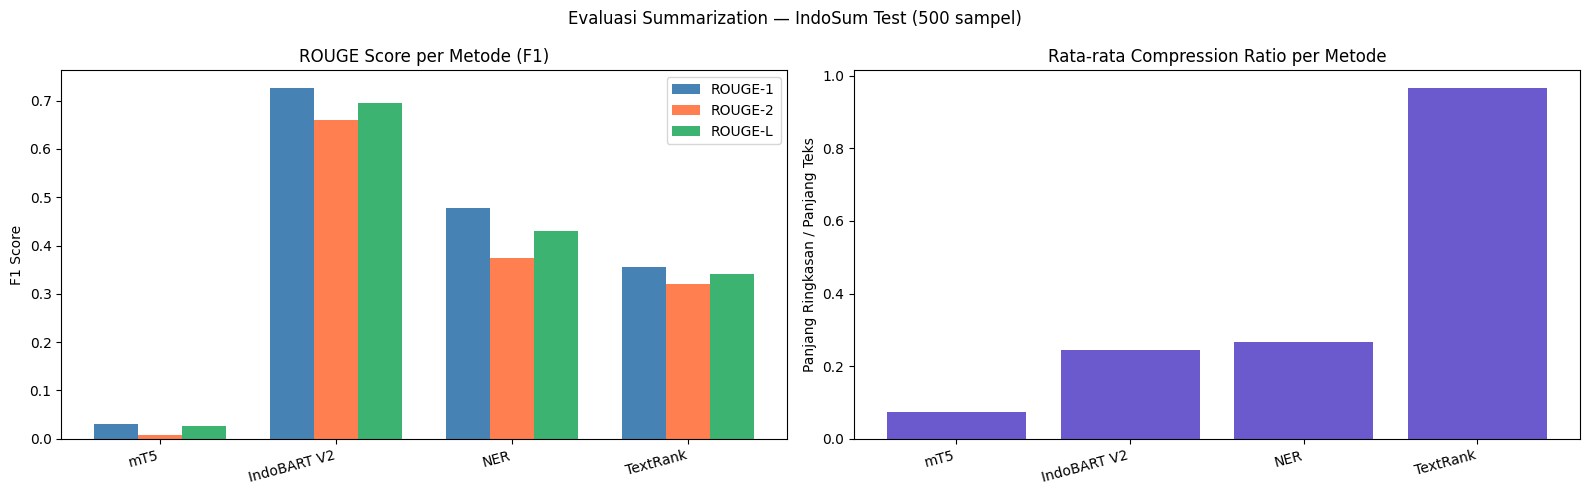

In [39]:
# Visualisasi: ROUGE score dan compression ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

x      = range(len(results_df))
width  = 0.25
colors = ["steelblue", "coral", "mediumseagreen"]

for i, metric in enumerate(["ROUGE-1", "ROUGE-2", "ROUGE-L"]):
    ax1.bar([xi + i * width for xi in x], results_df[metric], width,
            label=metric, color=colors[i])
ax1.set_xticks([xi + width for xi in x])
ax1.set_xticklabels(results_df.index, rotation=15, ha="right")
ax1.set_title("ROUGE Score per Metode (F1)")
ax1.set_ylabel("F1 Score")
ax1.legend()

ax2.bar(results_df.index, results_df["Compression Ratio"], color="slateblue")
ax2.set_title("Rata-rata Compression Ratio per Metode")
ax2.set_ylabel("Panjang Ringkasan / Panjang Teks")
plt.xticks(rotation=15, ha="right")

plt.suptitle(f"Evaluasi Summarization — IndoSum Test ({N_TEST} sampel)")
plt.tight_layout()
plt.show()

In [40]:
# Perbandingan output side-by-side pada satu sampel
print("=" * 70)
print("Perbandingan Output — Sampel Pertama")
print("=" * 70)
print()
print("TEKS ASLI (200 karakter pertama):")
print(test_subset[0]["text"][:200])
print()
print("REFERENSI:")
print(test_subset[0]["summary"])
print()
for name, preds in all_methods:
    print(f"{name}:")
    print(preds[0][:200] if preds else "(kosong)")
    print()


Perbandingan Output — Sampel Pertama

TEKS ASLI (200 karakter pertama):
Jakarta , CNN Indonesia - - Dilansir AFP , seorang warga Mesir yang dipercaya sebagai wanita terberat di dunia masuk sebuah rumah sakit di Abu Dhabi Kamis ( 5 / 5 ) , dimana ia akan melanjutkan perawa

REFERENSI:
Eman Ahmed Abd El Aty memiliki berat badan mencapai 500 kilogram sebelum menjalankan operasi di Mumbai Maret lalu dimana ia mengurangi seperlima dari berat badannya . Abd El Aty diberi diet cairan khusus selama berada di India yang bertujuan menurunkan berat badan . Kini , berat badannya telah turun drastis sebanyak 323 kilogram dalam tiga bulan . Sekarang berat badannya tinggal 176,6 kilogram .

mT5:
<extra_id_0> , ” ungkapnya ..

IndoBART V2:
Seorang warga Mesir yang dipercaya sebagai wanita terberat di dunia masuk sebuah rumah sakit di Abu Dhabi Kamis ( 5 / 5 ) , dimana ia akan melanjutkan perawatan setelah menjalankan operasi menurunkan 

NER:
Jakarta , CNN Indonesia - - Dilansir AFP , seorang warga Me

## Section 10: Kesimpulan

### Ringkasan Perbandingan 4 Metode

| Metode | Tipe | Kelebihan | Kekurangan |
|--------|------|-----------|------------|
| mT5-base | Abstraktif Multilingual | Ringkasan natural, support 101 bahasa | Tokenizer kurang efisien untuk Indonesia |
| IndoBART V2 | Abstraktif Indonesia | Vocabulary khusus Indonesia, lebih efisien | Monolingual, hanya Indonesia+Inggris |
| NER-Based | Ekstraktif Rule-based | Fokus pada entitas penting | Tidak belajar dari data |
| TextRank | Ekstraktif Unsupervised | Cepat, tanpa GPU, tanpa training | Tidak menghasilkan kalimat baru |

### Model yang Tersimpan di `model/`

| Folder | Format | Isi |
|--------|--------|-----|
| `model/mt5-indosum/` | HuggingFace safetensors | mT5-base fine-tuned pada IndoSum |
| `model/indobart-v2-indosum/` | HuggingFace safetensors | IndoBART V2 fine-tuned pada IndoSum |
| `model/ner/` | HuggingFace safetensors | NER pipeline untuk Bahasa Indonesia |

### Interpretasi ROUGE

ROUGE yang lebih tinggi bukan selalu lebih baik:
- **TextRank/NER** ROUGE tinggi karena kalimat diambil langsung dari teks
- **mT5/IndoBART V2** ROUGE bisa lebih rendah meski kualitas konten lebih baik (kalimat baru)
- Untuk kasus dialek Indonesia nyata, model abstraktif lebih unggul karena bisa menghasilkan
  Bahasa Indonesia formal dari input dialek yang kosakatanya berbeda

### Limitasi & Langkah Selanjutnya

- Evaluasi hanya pada IndoSum (berita, bukan pengaduan dialek)
- Untuk dataset dialek asli: gunakan `dianlestari187/sovereign-dialect-indonesian`
- Fine-tuning Qwen2.5 dengan QLoRA tersedia di `notebook/training_from_try_dian.ipynb`

## Section 11: Export & Download Output

Zip setiap model hasil training agar bisa didownload dari Kaggle dan digunakan
untuk **inference lokal di laptop** (Mac M1/M2 via MPS, atau CPU).

| File ZIP | Isi | Ukuran Estimasi |
|----------|-----|-----------------|
| `mt5-indosum.zip` | mT5-base fine-tuned pada IndoSum | ~2.3 GB |
| `indobart-v2-indosum.zip` | IndoBART V2 fine-tuned pada IndoSum | ~1.5 GB |
| `ner.zip` | NER pipeline (BERT Indonesian) | ~430 MB |

Download dari Kaggle: tab **Output** → klik file `.zip` → tombol **Download**.

In [41]:
import shutil
from pathlib import Path

print("=" * 60)
print("Export Model — Zip untuk Download & Inference Lokal")
print("=" * 60)

zip_dir = Path('/kaggle/working') if IN_KAGGLE else OUTPUT_DIR

models_to_zip = [
    ("mt5-indosum",        MT5_PATH,         "mT5-base fine-tuned pada IndoSum"),
    ("indobart-v2-indosum", INDOBART_V2_PATH, "IndoBART V2 fine-tuned pada IndoSum"),
    ("ner",                NER_PATH,         "NER pipeline (cahya/bert-base-indonesian-NER)"),
]

print()
for slug, model_path, label in models_to_zip:
    src = Path(model_path)
    if not src.exists():
        print(f"  SKIP — {label}")
        print(f"         folder tidak ditemukan: {src}")
        continue
    out = str(zip_dir / slug)
    shutil.make_archive(out, 'zip', src.parent, src.name)
    size_mb = (zip_dir / (slug + '.zip')).stat().st_size / 1024 / 1024
    print(f"  {slug}.zip  →  {size_mb:.1f} MB  |  {label}")

print()
if IN_KAGGLE:
    print("Cara download dari Kaggle:")
    print("  1. Klik tab 'Output' di panel kanan notebook")
    print("  2. Cari file .zip → klik tombol Download")
    print()

print("Cara load lokal — Mac M1/M2 (Apple Silicon MPS):")
print()
print("  # Ekstrak zip ke: Project_Summarize_NLP/model/<nama-model>/")
print()
print("  from transformers import AutoTokenizer, AutoModelForSeq2SeqLM")
print("  import torch")
print()
print("  # Contoh load mT5")
print("  tokenizer = AutoTokenizer.from_pretrained('../model/mt5-indosum')")
print("  model     = AutoModelForSeq2SeqLM.from_pretrained('../model/mt5-indosum')")
print("  model     = model.to('mps')  # Apple Silicon GPU")
print()
print("  teks = 'summarize: <paste teks artikel atau pengaduan>'")
print("  inp  = tokenizer(teks, return_tensors='pt', max_length=512, truncation=True).to('mps')")
print("  out  = model.generate(**inp, max_new_tokens=128, num_beams=4)")
print("  print(tokenizer.decode(out[0], skip_special_tokens=True))")

Export Model — Zip untuk Download & Inference Lokal

  mt5-indosum.zip  →  2098.2 MB  |  mT5-base fine-tuned pada IndoSum
  indobart-v2-indosum.zip  →  2086.7 MB  |  IndoBART V2 fine-tuned pada IndoSum
  ner.zip  →  390.1 MB  |  NER pipeline (cahya/bert-base-indonesian-NER)

Cara download dari Kaggle:
  1. Klik tab 'Output' di panel kanan notebook
  2. Cari file .zip → klik tombol Download

Cara load lokal — Mac M1/M2 (Apple Silicon MPS):

  # Ekstrak zip ke: Project_Summarize_NLP/model/<nama-model>/

  from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
  import torch

  # Contoh load mT5
  tokenizer = AutoTokenizer.from_pretrained('../model/mt5-indosum')
  model     = AutoModelForSeq2SeqLM.from_pretrained('../model/mt5-indosum')
  model     = model.to('mps')  # Apple Silicon GPU

  teks = 'summarize: <paste teks artikel atau pengaduan>'
  inp  = tokenizer(teks, return_tensors='pt', max_length=512, truncation=True).to('mps')
  out  = model.generate(**inp, max_new_tokens=128,